In [2]:
!pip install geopandas
!pip install shapely
!pip install folium
!pip install contextily

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------- ----------------------------- 6.0/22.9 MB 33.8 MB/s eta 0:00:01
   ---------------------------------------  22.8/22.9 MB 66.3 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 54.5 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 73.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 81.6 MB/s  0:00:00

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   -

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

import yaml
from pathlib import Path

In [2]:
config_path = Path.cwd().parent / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

root = Path(config['project_root'])

In [3]:
df= pd.read_csv(root / "data" / "processed" / "cleaned_air_quality_bilbao_2015_2026.csv")
df.head()

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.0,28.0,9.0
1,2015-01-02,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,56.0,24.0,18.0,8.0
2,2015-01-03,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,48.0,33.0,21.0,8.0
3,2015-01-04,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,43.0,31.0,23.0,7.0
4,2015-01-05,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,29.0,18.0,11.0,5.0


In [4]:
print(df[["Latitude", "Longitude"]].head())

    Latitude  Longitude
0  43.362056  -3.022782
1  43.362056  -3.022782
2  43.362056  -3.022782
3  43.362056  -3.022782
4  43.362056  -3.022782


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27883 entries, 0 to 27882
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       27883 non-null  str    
 1   station    27883 non-null  str    
 2   Town       27883 non-null  str    
 3   Province   27883 non-null  str    
 4   Latitude   27883 non-null  float64
 5   Longitude  27883 non-null  float64
 6   NO2        27883 non-null  float64
 7   PM10       27883 non-null  float64
 8   PM2.5      27883 non-null  float64
 9   SO2        27883 non-null  float64
dtypes: float64(6), str(4)
memory usage: 3.0 MB


In [8]:
# Geometry
geometry = gpd.points_from_xy(
    df["Longitude"],
    df["Latitude"]
)

In [9]:
# GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry
)
gdf.head()

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2,geometry
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.0,28.0,9.0,POINT (-3.02278 43.36206)
1,2015-01-02,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,56.0,24.0,18.0,8.0,POINT (-3.02278 43.36206)
2,2015-01-03,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,48.0,33.0,21.0,8.0,POINT (-3.02278 43.36206)
3,2015-01-04,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,43.0,31.0,23.0,7.0,POINT (-3.02278 43.36206)
4,2015-01-05,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,29.0,18.0,11.0,5.0,POINT (-3.02278 43.36206)


In [10]:
# Coordinate Reference System (CRS)
gdf.set_crs(epsg=4326, inplace=True)
print(gdf.crs)

EPSG:4326


In [11]:
print(gdf.head())

         Date         station   Town Province   Latitude  Longitude   NO2  \
0  2015-01-01  ALGORTA_BBIZI2  Getxo  Bizkaia  43.362056  -3.022782  47.0   
1  2015-01-02  ALGORTA_BBIZI2  Getxo  Bizkaia  43.362056  -3.022782  56.0   
2  2015-01-03  ALGORTA_BBIZI2  Getxo  Bizkaia  43.362056  -3.022782  48.0   
3  2015-01-04  ALGORTA_BBIZI2  Getxo  Bizkaia  43.362056  -3.022782  43.0   
4  2015-01-05  ALGORTA_BBIZI2  Getxo  Bizkaia  43.362056  -3.022782  29.0   

   PM10  PM2.5  SO2                   geometry  
0  25.0   28.0  9.0  POINT (-3.02278 43.36206)  
1  24.0   18.0  8.0  POINT (-3.02278 43.36206)  
2  33.0   21.0  8.0  POINT (-3.02278 43.36206)  
3  31.0   23.0  7.0  POINT (-3.02278 43.36206)  
4  18.0   11.0  5.0  POINT (-3.02278 43.36206)  


In [12]:
print(type(gdf))

<class 'geopandas.geodataframe.GeoDataFrame'>


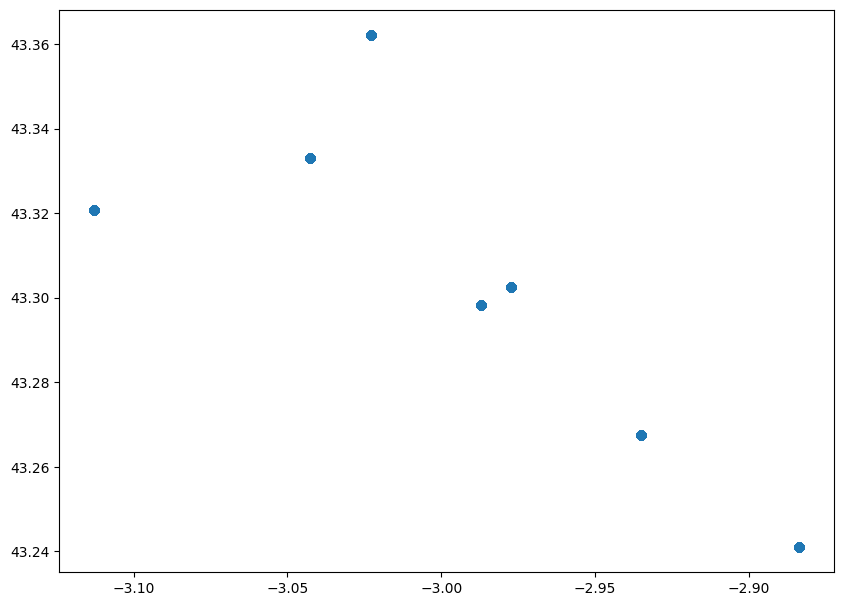

In [13]:
gdf.plot(figsize=(10, 10))
plt.show()

<Axes: >

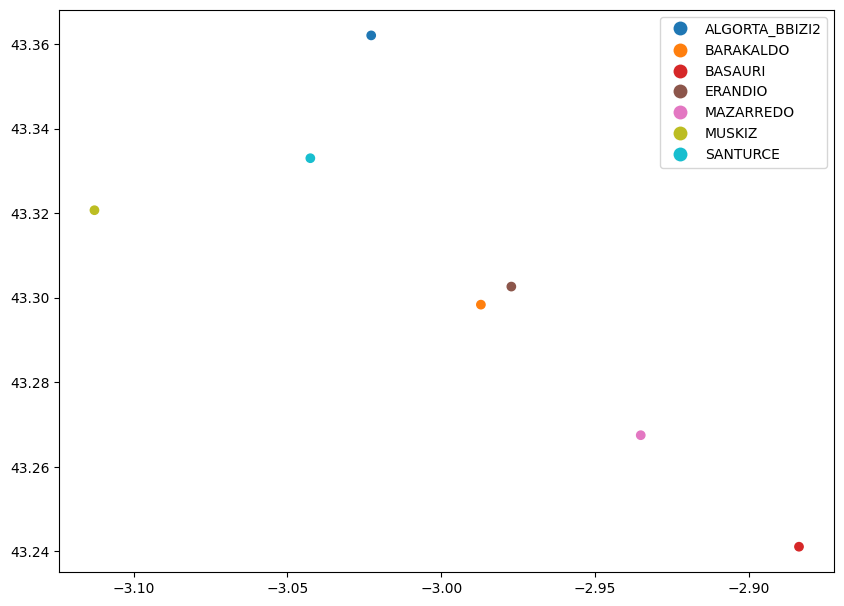

In [14]:
stations_gdf = gdf.drop_duplicates(
    subset="station"
)

stations_gdf.plot(
    figsize=(10,10),
    column="station",
    legend=True
)


In [15]:
# Reproject to Web Mercator for contextily
stations_map = stations_gdf.to_crs(
    epsg=3857
)

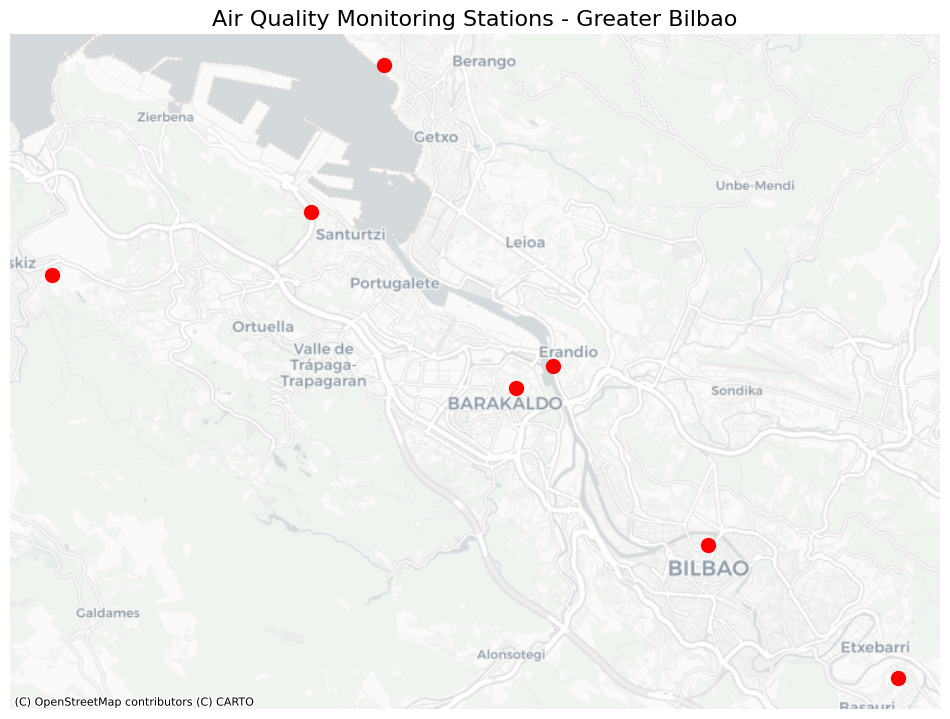

In [16]:
fig, ax = plt.subplots(
    figsize=(12, 12)
)

stations_map.plot(
    ax=ax,
    color="red",
    markersize=100
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

plt.title(
    "Air Quality Monitoring Stations - Greater Bilbao",
    fontsize=16
)

plt.axis("off")

plt.show()

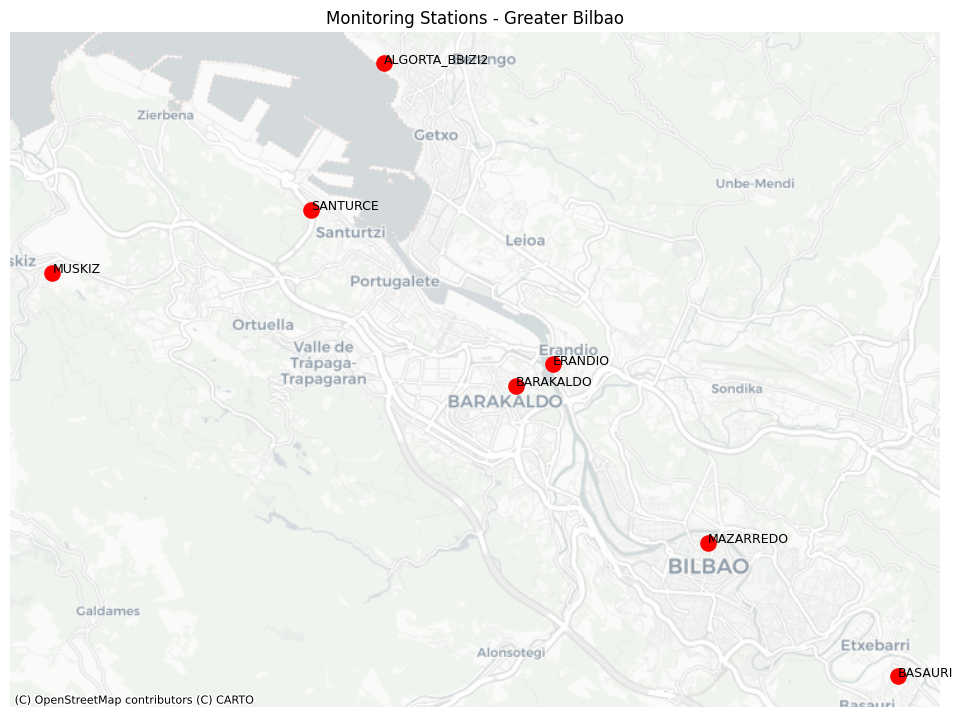

In [17]:
fig, ax = plt.subplots(
    figsize=(12, 12)
)

stations_map.plot(
    ax=ax,
    color="red",
    markersize=120
)

for x, y, label in zip(
    stations_map.geometry.x,
    stations_map.geometry.y,
    stations_map["station"]
):
    ax.text(
        x,
        y,
        label,
        fontsize=9
    )

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

plt.title(
    "Monitoring Stations - Greater Bilbao"
)

plt.axis("off")

plt.show()

In [21]:
mean_no2 = (
    gdf.groupby("station")["NO2"]
    .mean()
    .reset_index()
)
print(mean_no2.head())


          station        NO2
0  ALGORTA_BBIZI2  12.507414
1       BARAKALDO  20.575778
2         BASAURI  22.636208
3         ERANDIO  23.183489
4       MAZARREDO  25.773093


In [22]:
stations_pollution_no2 = stations_gdf.merge(
    mean_no2,
    on="station"
)

In [29]:
stations_pollution_no2


,Date,station,Town,Province,Latitude,Longitude,NO2_x,PM10,PM2.5,SO2,geometry,NO2_y
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.000000,28.000000,9.0,POINT (-3.02278 43.36206),12.507414
1,2015-01-01,BARAKALDO,Barakaldo,Bizkaia,43.298379,-2.987133,51.0,25.917387,21.825409,13.0,POINT (-2.98713 43.29838),20.575778
2,2015-01-01,BASAURI,Basauri,Bizkaia,43.241131,-2.883761,33.0,22.000000,14.216098,5.0,POINT (-2.88376 43.24113),22.636208
3,2015-01-01,ERANDIO,Erandio,Bizkaia,43.302653,-2.977240,52.0,41.889268,23.000000,10.0,POINT (-2.97724 43.30265),23.183489
4,2015-01-01,MAZARREDO,Bilbao,Bizkaia,43.267506,-2.935188,55.0,35.000000,20.543550,17.0,POINT (-2.93519 43.26751),25.773093
5,2015-01-01,MUSKIZ,Muskiz,Bizkaia,43.320713,-3.112716,27.0,18.000000,12.117439,8.0,POINT (-3.11272 43.32071),8.670130
6,2015-01-01,SANTURCE,Santurtzi,Bizkaia,43.333012,-3.042560,42.0,17.000000,14.000000,8.0,POINT (-3.04256 43.33301),18.734626


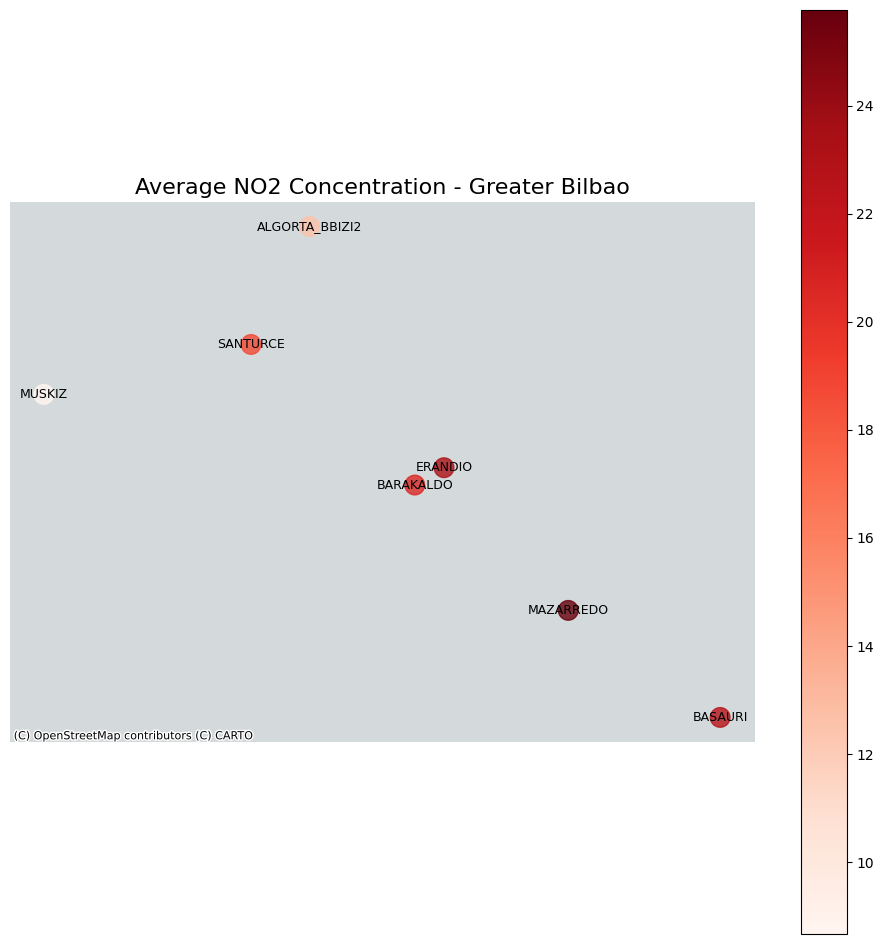

In [53]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

stations_pollution_no2.plot(
    column="NO2_y",
    cmap="Reds",
    legend=True,
    markersize=200,
    alpha=0.8,
    ax=ax 
)

for idx, row in stations_pollution_no2.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["station"],
        fontsize=9,
        ha="center",
        va="center"
    )

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

plt.title(
    "Average NO2 Concentration - Greater Bilbao",
    fontsize=16
)

plt.axis("off")

plt.savefig(
    r"C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\maps\no2_map.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [33]:
mean_pm10 = (
    gdf.groupby("station")["PM10"]
    .mean()
    .reset_index()
)
print(mean_pm10.head())

          station       PM10
0  ALGORTA_BBIZI2  20.310430
1       BARAKALDO  19.686314
2         BASAURI  19.832205
3         ERANDIO  17.705748
4       MAZARREDO  16.869806


In [34]:
stations_pollution_pm10 = stations_gdf.merge(
    mean_pm10,
    on="station"
)
stations_pollution_pm10

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10_x,PM2.5,SO2,geometry,PM10_y
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.000000,28.000000,9.0,POINT (-3.02278 43.36206),20.310430
1,2015-01-01,BARAKALDO,Barakaldo,Bizkaia,43.298379,-2.987133,51.0,25.917387,21.825409,13.0,POINT (-2.98713 43.29838),19.686314
2,2015-01-01,BASAURI,Basauri,Bizkaia,43.241131,-2.883761,33.0,22.000000,14.216098,5.0,POINT (-2.88376 43.24113),19.832205
3,2015-01-01,ERANDIO,Erandio,Bizkaia,43.302653,-2.977240,52.0,41.889268,23.000000,10.0,POINT (-2.97724 43.30265),17.705748
4,2015-01-01,MAZARREDO,Bilbao,Bizkaia,43.267506,-2.935188,55.0,35.000000,20.543550,17.0,POINT (-2.93519 43.26751),16.869806
5,2015-01-01,MUSKIZ,Muskiz,Bizkaia,43.320713,-3.112716,27.0,18.000000,12.117439,8.0,POINT (-3.11272 43.32071),11.505747
6,2015-01-01,SANTURCE,Santurtzi,Bizkaia,43.333012,-3.042560,42.0,17.000000,14.000000,8.0,POINT (-3.04256 43.33301),13.971074


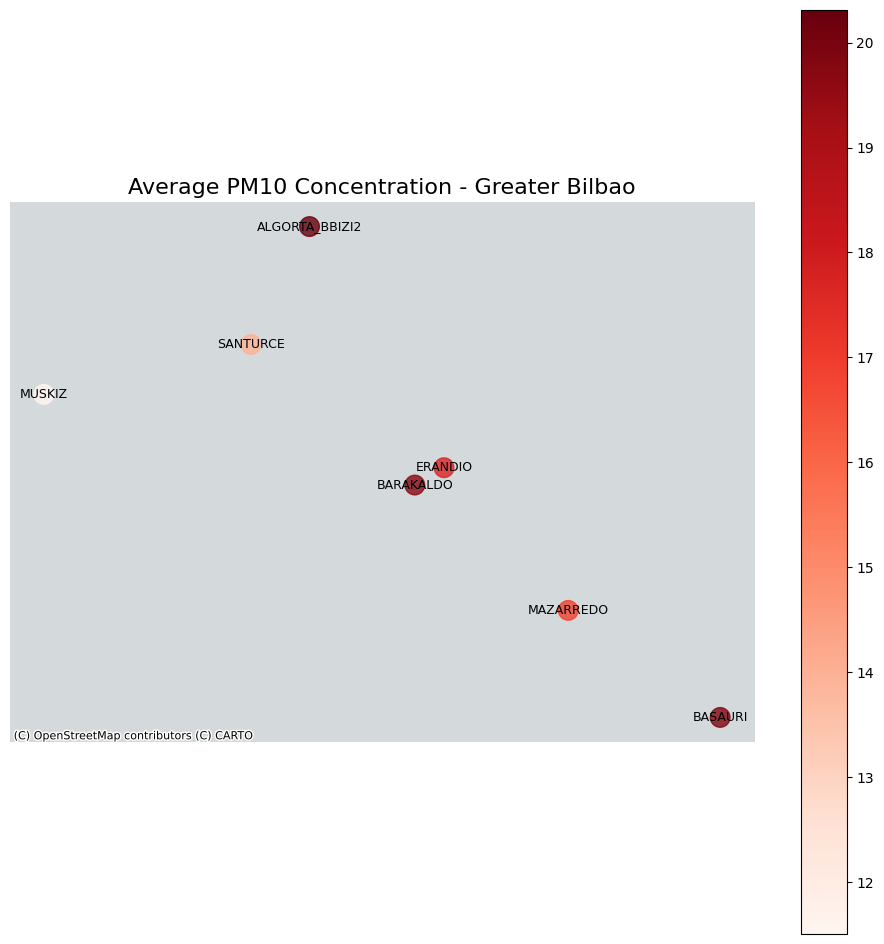

In [54]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

stations_pollution_pm10.plot(
    column="PM10_y",
    cmap="Reds",
    legend=True,
    markersize=200,
    alpha=0.8,
    ax=ax
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

for idx, row in stations_pollution_no2.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["station"],
        fontsize=9,
        ha="center",
        va="center"
    )

plt.title(
    "Average PM10 Concentration - Greater Bilbao",
    fontsize=16
)

plt.axis("off")

plt.savefig(
    r"C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\maps\pm10_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
gdf.columns

Index(['Date', 'station', 'Town', 'Province', 'Latitude', 'Longitude', 'NO2',
       'PM10', 'PM2.5', 'SO2', 'geometry'],
      dtype='str')

In [ ]:
mean_pm25 = (
    gdf.groupby("station")["PM2.5"]
    .mean()
    .reset_index()
)


stations_pollution_pm25 = stations_gdf.merge(
    mean_pm25,
    on="station"
)
stations_pollution_pm25

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5_x,SO2,geometry,PM2.5_y
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.000000,28.000000,9.0,POINT (-3.02278 43.36206),9.240742
1,2015-01-01,BARAKALDO,Barakaldo,Bizkaia,43.298379,-2.987133,51.0,25.917387,21.825409,13.0,POINT (-2.98713 43.29838),12.419754
2,2015-01-01,BASAURI,Basauri,Bizkaia,43.241131,-2.883761,33.0,22.000000,14.216098,5.0,POINT (-2.88376 43.24113),11.415270
3,2015-01-01,ERANDIO,Erandio,Bizkaia,43.302653,-2.977240,52.0,41.889268,23.000000,10.0,POINT (-2.97724 43.30265),9.102515
4,2015-01-01,MAZARREDO,Bilbao,Bizkaia,43.267506,-2.935188,55.0,35.000000,20.543550,17.0,POINT (-2.93519 43.26751),9.722995
5,2015-01-01,MUSKIZ,Muskiz,Bizkaia,43.320713,-3.112716,27.0,18.000000,12.117439,8.0,POINT (-3.11272 43.32071),6.500989
6,2015-01-01,SANTURCE,Santurtzi,Bizkaia,43.333012,-3.042560,42.0,17.000000,14.000000,8.0,POINT (-3.04256 43.33301),9.386218


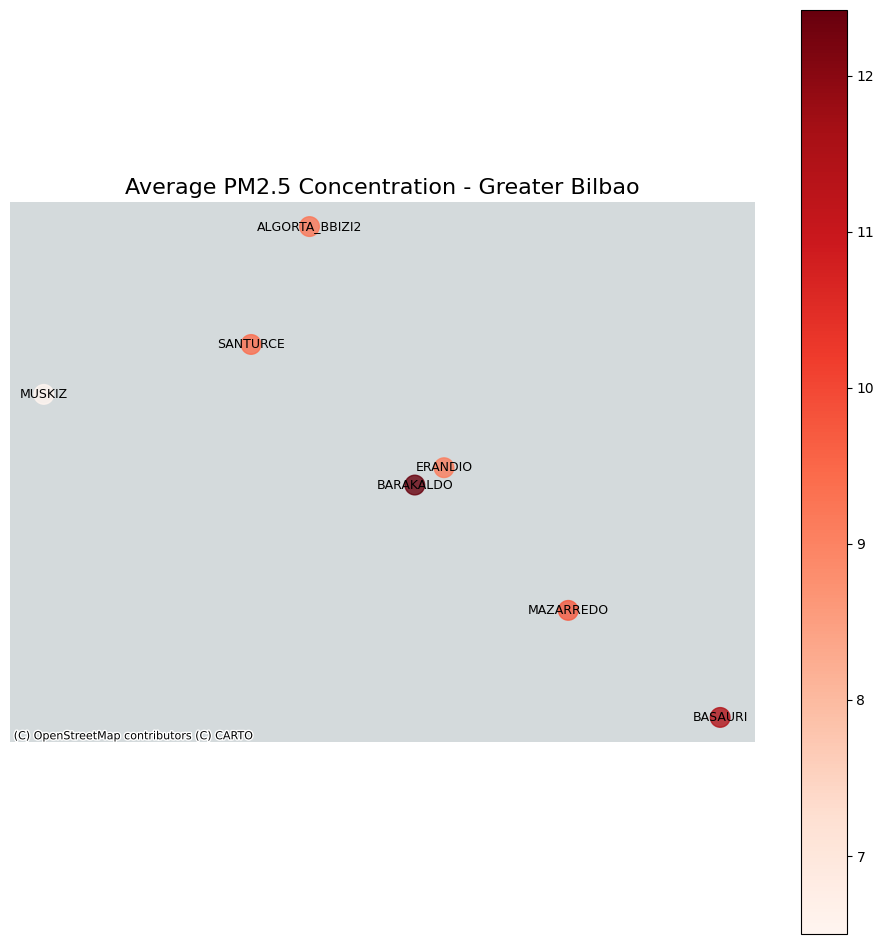

In [55]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

stations_pollution_pm25.plot(
    column="PM2.5_y",
    cmap="Reds",
    legend=True,
    markersize=200,
    alpha=0.8,
    ax=ax
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

for idx, row in stations_pollution_no2.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["station"],
        fontsize=9,
        ha="center",
        va="center"
    )

plt.title(
    "Average PM2.5 Concentration - Greater Bilbao",
    fontsize=16
)

plt.axis("off")

plt.savefig(
    r"C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\maps\pm25_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
mean_so2 = (
    gdf.groupby("station")["SO2"]
    .mean()
    .reset_index()
)


stations_pollution_so2 = stations_gdf.merge(
    mean_so2,
    on="station"
)
stations_pollution_so2

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2_x,geometry,SO2_y
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.000000,28.000000,9.0,POINT (-3.02278 43.36206),4.630052
1,2015-01-01,BARAKALDO,Barakaldo,Bizkaia,43.298379,-2.987133,51.0,25.917387,21.825409,13.0,POINT (-2.98713 43.29838),5.605900
2,2015-01-01,BASAURI,Basauri,Bizkaia,43.241131,-2.883761,33.0,22.000000,14.216098,5.0,POINT (-2.88376 43.24113),3.415921
3,2015-01-01,ERANDIO,Erandio,Bizkaia,43.302653,-2.977240,52.0,41.889268,23.000000,10.0,POINT (-2.97724 43.30265),4.312068
4,2015-01-01,MAZARREDO,Bilbao,Bizkaia,43.267506,-2.935188,55.0,35.000000,20.543550,17.0,POINT (-2.93519 43.26751),6.183821
5,2015-01-01,MUSKIZ,Muskiz,Bizkaia,43.320713,-3.112716,27.0,18.000000,12.117439,8.0,POINT (-3.11272 43.32071),4.684392
6,2015-01-01,SANTURCE,Santurtzi,Bizkaia,43.333012,-3.042560,42.0,17.000000,14.000000,8.0,POINT (-3.04256 43.33301),4.754940


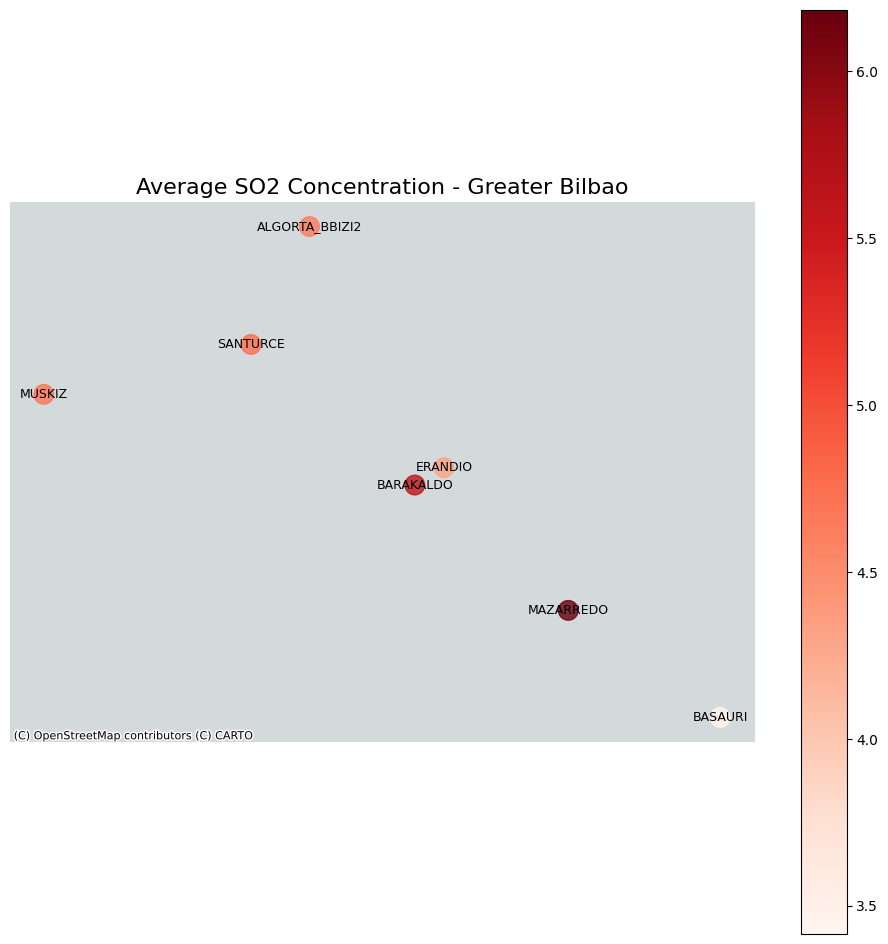

In [56]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

stations_pollution_so2.plot(
    column="SO2_y",
    cmap="Reds",
    legend=True,
    markersize=200,
    alpha=0.8,
    ax=ax
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

for idx, row in stations_pollution_no2.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["station"],
        fontsize=9,
        ha="center",
        va="center"
    )

plt.title(
    "Average SO2 Concentration - Greater Bilbao",
    fontsize=16
)

plt.axis("off")

plt.savefig(
    r"C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\maps\so2_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Analyzing these patterns requires looking at the geography of the Nervión Fuerte/Ibaizabal estuary, the distribution of heavy industry, transportation corridors (like the A-8 highway), and urban density.

# 1. Pollutant-by-Pollutant Spatial Assessment

## 📊 Nitrogen Dioxide ($\text{NO}_2$)

•	Scale Range: $\sim 8$ to $>25 \, \mu\text{g/m}^3$

•	Hotspots: Mazarredo (highest, $>25$), followed closely by Basauri, Barakaldo, and Erandio.

•	Coldspots: Muskiz ($\sim 8$) and Algorta ($\sim 11$).

•	Data Science Insight: $\text{NO}_2$ is a classic proxy for traffic emissions and high-temperature combustion. Mazarredo sits right in the dense urban core of Bilbao, heavily impacted by traffic volume and urban canyon effects. Barakaldo and Erandio border major highway corridors flanking the estuary. Conversely, Muskiz (coastal/rural fringe) and Algorta (residential coastal) benefit from strong marine ventilation and lower traffic density.


## 💨 Coarse Particulate Matter ($\text{PM}_{10}$)

•	Scale Range: $\sim 11$ to $>20 \, \mu\text{g/m}^3$

•	Hotspots: Basauri and Algorta ($>20$). Barakaldo is also highly elevated.

•	Coldspots: Muskiz ($11$) and Santurce ($\sim 13$).

•	Data Science Insight: The high $\text{PM}_{10}$ in Basauri aligns with its heavy industrial profile (steelworks and manufacturing) combined with its inland valley topography, which traps larger particles. The high reading at Algorta is intriguing—given its low $\text{NO}_2$, this is highly likely driven by natural marine aerosols (sea salt) rather than combustion, an important distinction in coastal environmental modeling


## 🔬 Fine Particulate Matter ($\text{PM}_{2.5}$)

•	Scale Range: $\sim 6.5$ to $>12.5 \, \mu\text{g/m}^3$

•	Hotspots: Barakaldo ($>12.5$) and Basauri ($\sim 12$).

•	Coldspots: Muskiz ($\sim 6.5$).

•	Data Science Insight: Unlike $\text{PM}_{10}$, $\text{PM}_{2.5}$ is dominated by anthropogenic combustion (diesel vehicles, industrial furnaces). The severe hotspot in Barakaldo points to a concentrated mix of intense road traffic (A-8 intersection) and residual urban-industrial emissions. Mazarredo and Erandio show moderate-to-high levels, confirming a strong urban traffic signature.


## 🪵 Sulfur Dioxide ($\text{SO}_2$)

•	Scale Range: $\sim 3.4$ to $>6.2 \, \mu\text{g/m}^3$

•	Hotspots: Mazarredo ($>6.2$). Muskiz, Santurce, and Algorta show moderate, uniform values ($\sim 4.5 - 5.0$).

•	Coldspots: Basauri ($<3.5$).

•	Data Science Insight: $\text{SO}_2$ is traditionally linked to sulfur-rich fuel combustion (refineries, heavy shipping, coal). The elevation in Mazarredo may point to residential commercial heating or localized urban sources. The moderate levels in Muskiz and Santurce correlate perfectly with the presence of the Petronor refinery in Muskiz and port activities in Santurce.


# 2. Integrated Spatial Typologies (Zonal Clustering)

By cross-referencing all four maps, we can identify three distinct environmental zones in Greater Bilbao:

## 🏭 Zone A: The Industrial & Logistics Corridors (Basauri & Barakaldo)

•	Profile: High across almost all categories ($\text{PM}_{10}$, $\text{PM}_{2.5}$, $\text{NO}_2$).

•	Dynamics: These areas act as the industrial lungs and freight backbones of the metropolitan area. The confluence of metallurgy, manufacturing, and heavy duty vehicle traffic creates a high-exposure zone for particulate matter.


## 🚗 Zone B: The Urban Core (Mazarredo & Erandio)

•	Profile: Peak $\text{NO}_2$ and $\text{SO}_2$, moderate-to-high $\text{PM}_{2.5}$, moderate $\text{PM}_{10}$.

•	Dynamics: Classic urban traffic profile. Topographic confinement along the river valley limits lateral dispersion, causing vehicle exhaust ($\text{NO}_x$) to concentrate in the city center


## 🌊 Zone C: The Coastal/Peripheral Buffer (Muskiz & Algorta)

•	Profile: Generally low combustion gases ($\text{NO}_2$), but selective spikes (e.g., Marine $\text{PM}_{10}$ in Algorta; industrial $\text{SO}_2$ in Muskiz).

•	Dynamics: Strong meteorological cleaning due to coastal winds, though localized industrial assets still leave a chemical footprint.